<a href="https://colab.research.google.com/github/UW-CTRL/lmc-exercises/blob/main/exercises/04a_control_barrier_function.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Control Barrier Function Filter

In this problem, you will implement a CBF-QP safety filter.

To start off, we will restrict ourselves to a simple 1D system so that you can verify your results analytically if needed.


 but note that the theory extends to higher dimensional problems, and try to keep your code general so that it could still work on a different system and choice of CBF.

Consider the following 1D single integator dynamics $\dot{x} = u$ and let $b(x) = x^2 - 1$.
In this problem, $b(x)=x^2-1$ defines a safety condition (e.g., a set where $b(x)\leq 0$ is safe), and $f(x, u) = u$ describes the system's dynamics.
The Lie derivative $\nabla b(x)^T f(x, u)$ therefore describes how $b(x)$ changes due to the control input $u$, and is central to Control Barrier Function (CBF) approaches for enforcing safety constraints through feedback or filtering.

The Lie derivative of a function $b(x)$ with respect to the dynamics $f(x, u)$ measures how $b(x)$ changes as the system evolves according to those dynamics.

Mathematically, the Lie derivative is given by $\nabla b(x)^T f(x, u)$, where $\nabla b(x)$ is the gradient of $b$ with respect to $x$.
This expression tells us the instantaneous rate of change of $b(x)$ when the state $x$ flows along the vector field defined by $f(x, u)$.



In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import functools
import cvxpy as cp
import numpy as np


In [3]:
def f(x, u):
    return u

def b(x):
    return x**2 - 1


Plot the control barrier function

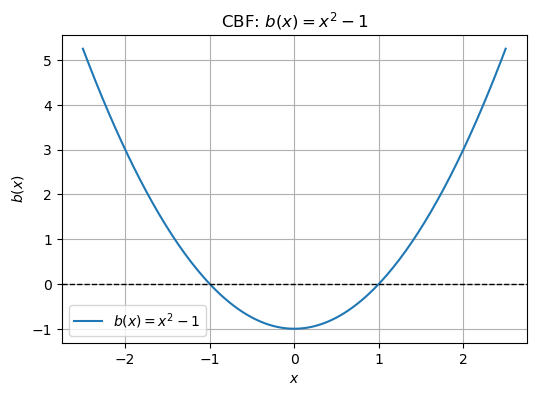

In [29]:

x_vals = jnp.linspace(-2.5, 2.5, 200)
b_vals = b(x_vals)

plt.figure(figsize=(6,4))
plt.plot(x_vals, b_vals, label="$b(x) = x^2 - 1$")
plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.xlabel("$x$")
plt.ylabel("$b(x)$")
plt.title("CBF: $b(x) = x^2 - 1$")
plt.grid(True)
plt.legend()
plt.show()

### (a) Compute the Lie derivative $\nabla b(x)^Tf(x,u)$

Verify the correctness of your implementation by deriving the analytic expression and comparing some values.



In [9]:
def _lie_derivative(dynamics_func, cbf_func, state, control):

    # TODO: compute the Lie derivative using JAX
    ###### add your code here
    # HINT: take a look at jax.jvp
    tangents = (dynamics_func(state, control),)
    primals = (state,)
    b_val, lie = jax.jvp(cbf_func, primals, tangents)
    return lie
    ###### end of add your code here

 
def analytic_lie_derivative(state, control):

    # TODO: compute the Lie derivative analytically
    ###### add your code here
    lie = 2*state*control
    return lie
    ###### end of add your code here

lie_derivative = functools.partial(_lie_derivative, f, b)



In [ ]:
# check if the implementation is correct
key = jax.random.PRNGKey(0)
bs = 128
state = jax.random.uniform(key, (bs, 1))
control = jax.random.uniform(key, (bs, 1))
close = jnp.allclose(jax.vmap(lie_derivative, in_axes=(0, 0))(state, control), analytic_lie_derivative(state, control))

if close:
    print("wahooo!")
else:
    print("NNNOOOOOOO!")


wahooo!


### (b) Solving the CBF-QP

Consider a scenario where your desired control input is $u_\mathrm{des} = 0.5$, aiming to move in the positive $x$-direction at constant velocity.
However, a safety constraint requires that $x^2 \geq 1$ at all times; this means the system must stay at least 1 unit away from the origin.

The Control Barrier Function (CBF) safety filter will adjust the control input to be as close as possible to $u_\mathrm{des}$, but only if it can do so while satisfying the CBF constraint.

The CBF-QP (Quadratic Program) can be formulated as follows:
$$
u_\mathrm{safe}(x) = \underset{u}{\text{argmin}} \| u - u_\mathrm{des}\|_2^2 \quad \text{subject to} \quad \nabla b(x)^\top f(x,u) \geq -\alpha\big(b(x)\big)
$$
In this optimization problem, the objective is quadratic and the constraint is linear in $u$.
For simplicity, assume there are no other constraints on the control input.

Let the class-$\mathcal{K}$ function $\alpha(z) = az$ with $a = 0.5$.

**Task:**  
Use `cvxpy` to solve the CBF-QP for the following values of $x$: $x = -3$, $x = -2$, and $x = -1.1$.

Report the corresponding safe control values $u_\mathrm{safe}(x)$ for each state.

**Hint:**  
The `Parameter` class in `cvxpy` is convenient for updating problem parameters, such as the state $x$, without reconstructing the entire optimization problem.


In [17]:
# TODO: implement the CBF-QP safety filter
##### add your code here
# NOTE: cvxpy does not support jax.numpy arrays, so we need to convert to numpy arrays
# set up CVXPY variables and parameters
x = cp.Parameter()  # state variable
u = cp.Variable()  # control variable
u_des = cp.Parameter()  # desired control input
u_des.value = 0.5  # desired control input

a = 0.5  # class K function parameter
objective = cp.Minimize(cp.sum_squares(u - u_des))
constraints = [2 * x * u >= -a * b(x)]
problem = cp.Problem(objective, constraints)

# solve the CBF-QP for each initial state
x_values = [-3, -2, -1.1]

for x_val in x_values:
    x.value = x_val
    problem.solve()
    print (f"Initial state: {x.value:.1f},\tSafe, optimal control: {u.value:.3f},\tCBF value: {b(x.value):.3f}")
##### end of add your code here


Initial state: -3.0,	Safe, optimal control: 0.500,	CBF value: 8.000
Initial state: -2.0,	Safe, optimal control: 0.375,	CBF value: 3.000
Initial state: -1.1,	Safe, optimal control: 0.048,	CBF value: 0.210


### (c) Applying the CBF Safety Filter
In this task, you will investigate the effect of the control barrier function (CBF) safety filter on the system dynamics.

**Instructions:**
- Simulate the system starting from the initial state $x = -5$, using a desired control input $u_\mathrm{des} = 0.5$.
- At each step, apply the CBF safety filter to compute the safe control $u_\mathrm{safe}$ before updating the state.
- Consider four values of the parameter $a$ in the class-$\mathcal{K}$ function $\alpha(z) = az$, specifically: $a = 2$, $a = 1$, $a = 0.5$, and $a = 0.1$.
- For each value of $a$, simulate and plot the resulting state and control input trajectories over time.

**Simulation details:**
- Use a time step of $\Delta t = 0.05$.
- Run the simulation for 500 time steps.

**Discussion:**
- Compare the trajectories for the different values of $a$.
- Comment on how the choice of $a$ affects the system behavior and the conservatism of the safety filter.
- What practical role does the parameter $a$ play in shaping the system's response?

*Note:* While CBF theory is designed for continuous-time systems, we are applying it here in discrete time for simulation purposes. This can lead to certain practical challenges (see [this paper](https://arxiv.org/abs/2404.12329) for more details), but using a sufficiently small time step is generally effective for our purposes.


In [50]:
# TODO: implement the CBF-QP safety filter
##### add your code here
# you may need some helper functions 
# you may need to loop through the different values of a
# you will need to write your own plotting code

# simulation parameters
dt = 0.05
n_timesteps = 500
tf = dt*n_timesteps
ts = np.arange(0,tf,dt)

x0 = -5 # initial state
u_des = 0.5 # desired control
a_values = [2, 1, 0.5, 0.1] # different class-K function scalar parameters


def solve_trajectory(a):
    u = cp.Variable()  # control variable
    x = cp.Parameter()  # param representing the current state
    # we can't make x a variable and optimize over the entire trajectory because 
    # the CBF constraint becomes quadratic (nonconvex) if both x and u are variables.
    
    objective = cp.Minimize(cp.sum_squares(u - u_des))
    cbf_constraint = analytic_lie_derivative(x, u) >= -a * b(x)
    constraints = [cbf_constraint]
    problem = cp.Problem(objective, constraints)

    x.value = x0

    xs = np.zeros(n_timesteps+1)
    xs[0] = x0

    us = np.zeros(n_timesteps)

    for i in range(n_timesteps):
        problem.solve()
        u_filtered = u.value
        us[i] = u_filtered

        # integrate dynamics
        xdot = f(x,u_filtered)
        x.value = x.value + xdot*dt # euler integration
        xs[i+1] = x.value

    return xs, us  

def plot_trajectory(axes, xs, us, a):
    t_states   = np.arange(n_timesteps + 1) * dt
    t_controls = np.arange(n_timesteps) * dt

    axes[0].plot(t_states, xs, label=f"$\alpha$={a}")
    axes[1].plot(t_controls, us, label=f"$\alpha$={a}")

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

for a in a_values:
    xs, us = solve_trajectory(a)
    plot_trajectory(axes, xs, us, a)

# Safe set boundaries
# axes[0].axhline(-1, color='k', linestyle='--', linewidth=1)
# axes[0].axhline( 1, color='k', linestyle='--', linewidth=1, label="Safe boundary")
axes[0].axhspan(-1,  1, color='red', alpha=0.2, label="unsafe")
axes[1].axhline(u_des, color='m', linestyle='--', linewidth=2, alpha=0.5, label="Desired control")

axes[0].set_ylabel("State $x$")
axes[1].set_ylabel("Control $u$")
axes[1].set_xlabel("Time (s)")
axes[0].set_title("Trajectories under CBF-QP safety filter")

for ax in axes:
    ax.legend()
    ax.grid(alpha=0.3)

# plt.tight_layout()
plt.show()

##### end of add your code here


ValueError: 
$lpha$=2
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

<Figure size 800x600 with 2 Axes>